imports

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sympy.printing.pretty.pretty_symbology import line_width

Getting Reference data using Ordinary Least Squares(OLS) method:

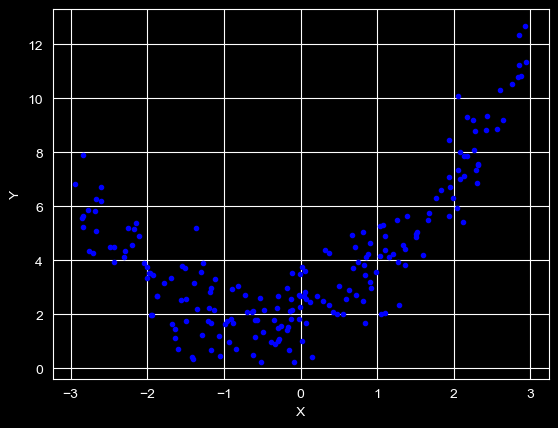

In [5]:
#data generation y=0.8x^2 + 0.9x + 2
x = 6 * np.random.rand(200,1) - 3
y = 0.8 * x**2 + 0.9 * x + 2 +np.random.randn(200,1)
plt.plot(x,y,'b.')
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

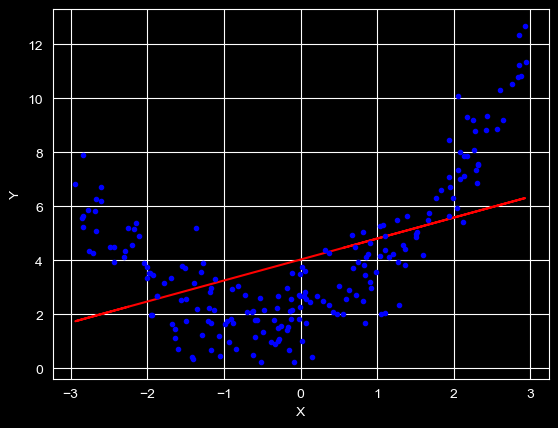

0.38315285596676885

In [6]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=2)
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)

plt.plot(x_train,lr.predict(x_train),color='r')
plt.plot(x,y,"b.")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()
r2_score(y_test,y_pred)

In [7]:
poly=PolynomialFeatures(degree=2,include_bias=True)
x_train_trans=poly.fit_transform(x_train)
x_test_trans=poly.transform(x_test)
lr=LinearRegression()
lr.fit(x_train_trans,y_train)
y_pred=lr.predict(x_test_trans)
print(lr.coef_)
print(lr.intercept_)
r2_score(y_test,y_pred)

[[0.         0.87915578 0.81511269]]
[1.97143025]


0.8758171667832639

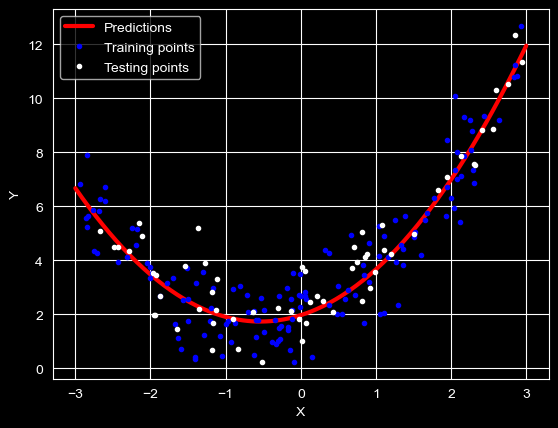

In [8]:
x_new=np.linspace(-3,3,200).reshape(200,1)
x_new_poly=poly.transform(x_new)
y_new=lr.predict(x_new_poly)
plt.plot(x_new,y_new,"r-",linewidth=3, label="Predictions")
plt.plot(x_train,y_train,"b.", label="Training points")
plt.plot(x_test,y_test,"w." ,label="Testing points")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

In [9]:
def polynomial_regression(degree):
    x_new=np.linspace(-3,3,100).reshape(100,1)
    x_new_poly=poly.transform(x_new)
    polybig_features=PolynomialFeatures(degree=degree,include_bias=False)
    std_scaler=StandardScaler()
    lin_reg=LinearRegression()
    polynomial_regression = Pipeline([
        ('poly_features', polybig_features),
    ('std_scaler', std_scaler),
    ('lin_reg', lin_reg),])
    polynomial_regression.fit(x,y)
    y_newbig=polynomial_regression.predict(x_new)
    plt.plot(x_new,y_newbig,"r",label="Degree "+str(degree),linewidth=2)
    plt.plot(x_train,y_train,"b.",linewidth=3)
    plt.plot(x_test,y_test,"w.",linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.axis([-3,3,0,10])
    plt.show()

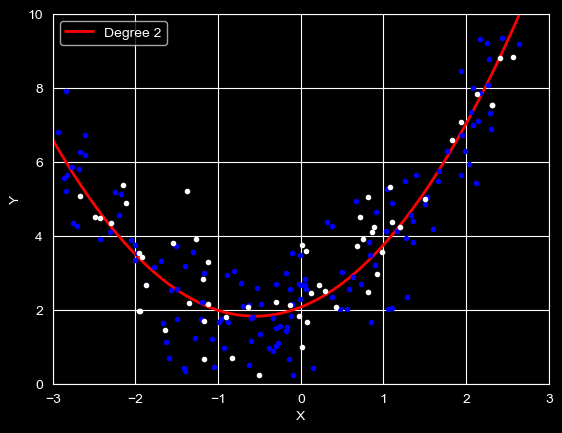

In [10]:
polynomial_regression(2)

In [11]:
# 3D polynomial regression (2 input features and 1 output feature)
x = 7 * np.random.rand(100,1) - 2.8
y = 7 * np.random.rand(100,1) - 2.8
z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y +2 + np.random.randn(100, 1) # z = x^2 + y^2 + 0.2x + 0.2y+0.1xy + 2
import plotly.express as px
df=px.data.iris()
fig=px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.show()

In [12]:
#Use multiple_linear_regression to find the bestfit hyperplane
lr=LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)
x_input=np.linspace(x.min(),x.max(),10)
y_input=np.linspace(y.min(),y.max(),10)
xg,yg=np.meshgrid(x_input,y_input)
final=np.vstack((xg.ravel().reshape(1,100),yg.ravel().reshape(1,100))).T
z_final=lr.predict(final).reshape(10,10)
import plotly.graph_objects as go
fig=px.scatter_3d(df,x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.add_trace(go.Surface(x=x_input,y=y_input, z=z_final))
fig.show()

In [13]:
x_multi=np.array([x,y]).reshape(100,2)
poly=PolynomialFeatures(degree=3)
x_multi_trans=poly.fit_transform(x_multi)
print("Input",poly.
print("Output",poly.n_output_features_)
print("Powers\n",poly.powers_)


AttributeError: 'PolynomialFeatures' object has no attribute 'n_features_in'

In [122]:
x_multi_trans.shape

(100, 10)

In [123]:
lr=LinearRegression()
lr.fit(x_multi_trans,z)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [124]:
x_test_multi=poly.transform(final)
z_final=lr.predict(x_multi_trans).reshape(10,10)

In [125]:
fig=px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.add_trace(go.Surface(x=x_input,y=y_input, z=z_final))
fig.update_layout(scene=dict(zaxis=dict(range=[0,35])))
fig.show()